In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle
import shap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../../Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

data = read_data(path)
data.head()

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 
months: 7, 8, 9, 10, 
years: 2022, 


,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.76105,39.69186,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.75488,0.334542,0.076456,-0.204286,-0.076456,0.150538,0.30311,0.239247,-0.30311,0.014625,0.025915,0.041455,0.025915,12.997875,16.053750,9.942,11.109776,4.927014,9.632237,3.969790,16.854539,5.921401,19.326126,8.137993,0.031663,0.031663,0.031663,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,10,0,0
1,22.72671,39.12560,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.24728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.189792,16.729583,9.650,9.988979,4.453562,11.092001,4.085860,17.402407,6.040758,21.116459,7.973342,0.189728,0.189728,0.189728,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,23.99842,39.24585,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.00175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.48510,39.29630,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.78626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.566179,1.498538,4.730211,-1.121905,12.474595,1.872899,17.555363,5.933300,48.433745,48.433745,48.433745,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,30,0,0
4,22.93502,39.38117,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.57293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.258333,NaN,12.890946,4.615169,12.072094,3.769438,17.947073,5.979803,22.062576,8.213274,0.003329,0.003329,0.003329,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,1,0,0


In [4]:
data.query('month >= 5 & month <= 10').shape

(3961, 69)

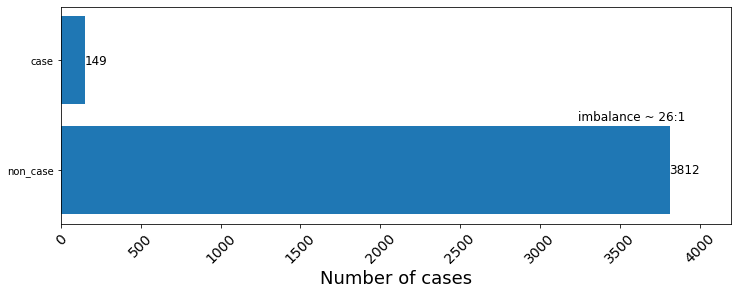

In [5]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [6]:
dataset = data.query('month >= 7 & month <= 10')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.76105,39.69186,2010-07-01,θεσσαλιας,αγιας,1,7,26,2010,0.201299,0.97953,-0.5,-0.866025,0.059241,-0.998244,661.8,10705.0,17.3,45.75488,0.545412,0.219638,-0.313503,-0.219638,0.535873,0.219986,-0.303468,-0.219986,0.041522,0.035609,0.031979,0.035609,23.576875,28.043125,19.110625,11.109776,4.927014,9.632237,3.969790,16.854539,5.921401,19.326126,8.137993,13.046218,32.593061,642.663714,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,7,14,0
1,22.72671,39.12560,2010-07-01,θεσσαλιας,αλμυρου,1,7,26,2010,0.201299,0.97953,-0.5,-0.866025,0.059241,-0.998244,905.4,16004.0,20.6,45.24728,0.415007,0.086710,-0.330265,-0.086710,0.414808,0.083511,-0.332519,-0.083511,0.048696,0.045171,0.021553,0.045171,25.001875,32.982917,17.020833,9.988979,4.453562,11.092001,4.085860,17.402407,6.040758,21.116459,7.973342,13.867823,28.965421,625.660995,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,8,15,0
2,23.99842,39.24585,2010-07-01,θεσσαλιας,αλοννησου,1,7,26,2010,0.201299,0.97953,-0.5,-0.866025,0.059241,-0.998244,129.6,3153.0,21.2,46.00175,-0.145451,0.257377,0.534709,-0.257377,-0.148065,0.273500,0.538216,-0.273500,0.011389,0.024575,0.026471,0.024575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.147022,163.878505,1092.618634,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,4,0
3,21.48510,39.29630,2010-07-01,θεσσαλιας,αργιθεας,1,7,26,2010,0.201299,0.97953,-0.5,-0.866025,0.059241,-0.998244,372.9,3515.0,9.3,44.78626,0.519347,0.244857,-0.235060,-0.244857,0.544798,0.256312,-0.244367,-0.256312,0.054467,0.042126,0.043739,0.042126,18.601538,23.216154,13.986923,-0.566179,1.498538,4.730211,-1.121905,12.474595,1.872899,17.555363,5.933300,12.997211,42.652267,979.922566,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,9,22,0
4,22.93502,39.38117,2010-07-01,θεσσαλιας,βολου,1,7,26,2010,0.201299,0.97953,-0.5,-0.866025,0.059241,-0.998244,385.6,138865.0,374.6,45.57293,0.409577,0.077304,-0.326707,-0.077304,0.399760,0.074964,-0.324585,-0.074964,0.047047,0.042319,0.026649,0.042319,27.221667,31.453333,22.990000,12.890946,4.615169,12.072094,3.769438,17.947073,5.979803,22.062576,8.213274,6.364254,25.289991,632.938418,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,10,12,0


In [7]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment',
       'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
       'lc_type1', 'lc_type2', 'lc_type3', 'lc

In [8]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 25


In [9]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,194,9,203,7.63%
1,2011,177,30,207,7.78%
2,2012,200,0,200,7.52%
3,2013,200,0,200,7.52%
4,2014,200,0,200,7.52%
5,2015,200,0,200,7.52%
6,2016,200,0,200,7.52%
7,2017,200,0,200,7.52%
8,2018,195,7,202,7.59%
9,2019,170,53,223,8.38%


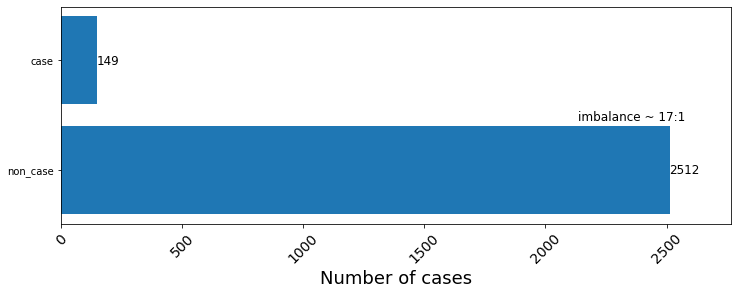

In [10]:
plot_imbalance(dataset)

In [11]:
majority_class = 0
near_u = 0
smote = 0.2
scaler = 'minmax'
weight_multiplier = 1
years_to_remove = [year for year in range(2012, 2018)]
years_to_remove.append(2021)
#years_to_remove = []

features_to_remove = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment','lc_prop2_assessment','lc_prop3_assessment','lw', 'qc','lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',]

#features_to_remove = []

In [12]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')


In [13]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler, majority_class, features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:6 || ##
Year: 2011 || w0:1, w1:7 || ##
Year: 2012 || w0:1, w1:7 || ##
Year: 2013 || w0:1, w1:7 || ##
Year: 2014 || w0:1, w1:7 || ##
Year: 2015 || w0:1, w1:7 || ##
Year: 2016 || w0:1, w1:7 || ##
Year: 2017 || w0:1, w1:7 || ##
Year: 2018 || w0:1, w1:6 || ##
Year: 2019 || w0:1, w1:9 || ##
Year: 2020 || w0:1, w1:6 || ##
Year: 2021 || w0:1, w1:7 || ##
Year: 2022 || w0:1, w1:8 || ##


In [14]:
feature_names

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')

In [15]:
len(feature_names)

48

In [41]:
indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi',
            'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
            'ndvi_std','ndmi_std', 'ndwi_std', 'ndbi_std',]

weather = ['lst', 'lst_day', 'lst_night',
               'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
               'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
               'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',]

demographic = ['area', 'population', 'population_density',]

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',]

spatiotemporal = ['month_sin', 'month_cos', 'week_sin', 'week_cos','eq_distance',]

entomological = ['mosq_pred', 'mosq_previous']

In [42]:
len(indicies+weather+demographic+geomorphological+spatiotemporal+entomological)

48

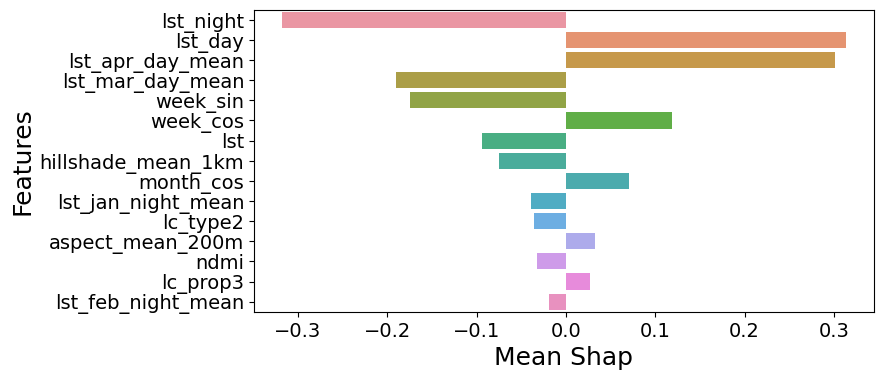

In [43]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

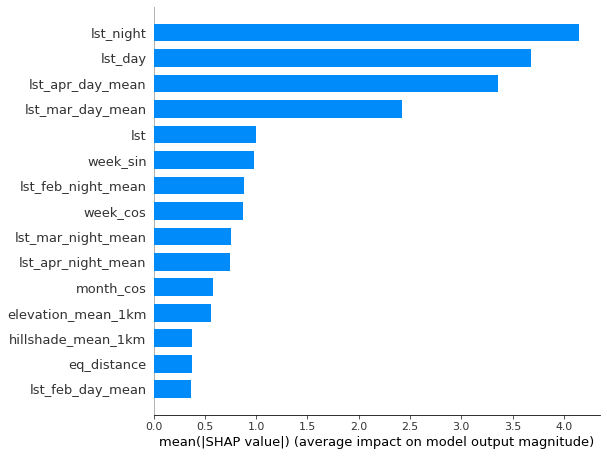

In [44]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

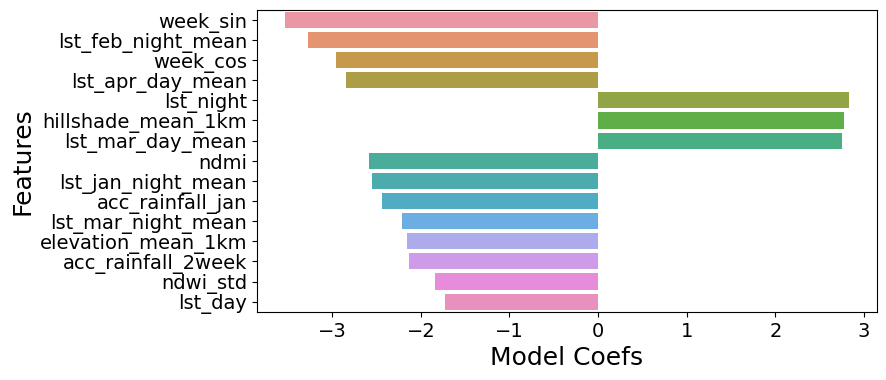

In [45]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [46]:
coefs

,features,weights
2,week_sin,-3.533087
26,lst_feb_night_mean,-3.274264
3,week_cos,-2.957829
29,lst_apr_day_mean,-2.846777
22,lst_night,2.826475
39,hillshade_mean_1km,2.772405
27,lst_mar_day_mean,2.749610
9,ndmi,-2.586146
24,lst_jan_night_mean,-2.549807
33,acc_rainfall_jan,-2.438737


In [47]:
shaps

,features,weights,weights_abs
22,lst_night,-0.317631,0.317631
21,lst_day,0.313073,0.313073
29,lst_apr_day_mean,0.300573,0.300573
27,lst_mar_day_mean,-0.190325,0.190325
2,week_sin,-0.174497,0.174497
3,week_cos,0.118675,0.118675
20,lst,-0.093591,0.093591
39,hillshade_mean_1km,-0.075373,0.075373
1,month_cos,0.070841,0.070841
24,lst_jan_night_mean,-0.038692,0.038692


,features,weights
1,weather,0.094108
4,spatiotemporal,0.076421
3,geomorphological,0.020264
0,rs_indicies,0.009936
2,demographic,0.007934
5,entomological,0.005802


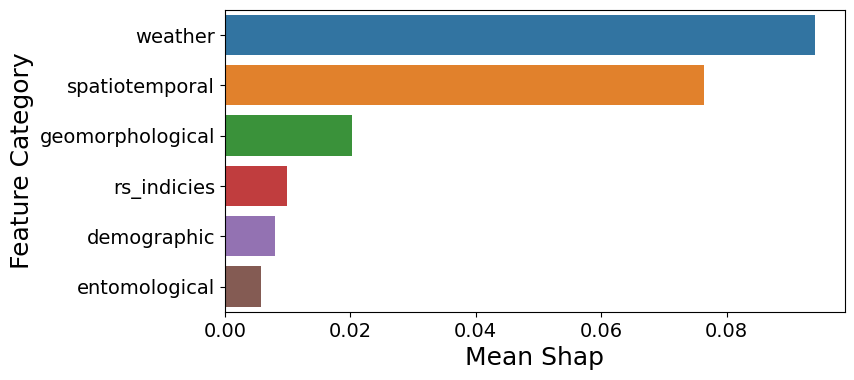

In [50]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_entomological = shaps.loc[shaps['features'].isin(entomological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 'demographic', 'geomorphological', 'spatiotemporal', 'entomological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_entomological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,6)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

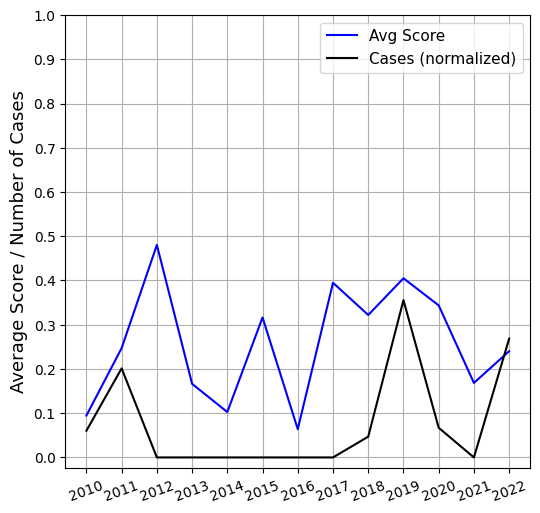

In [24]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

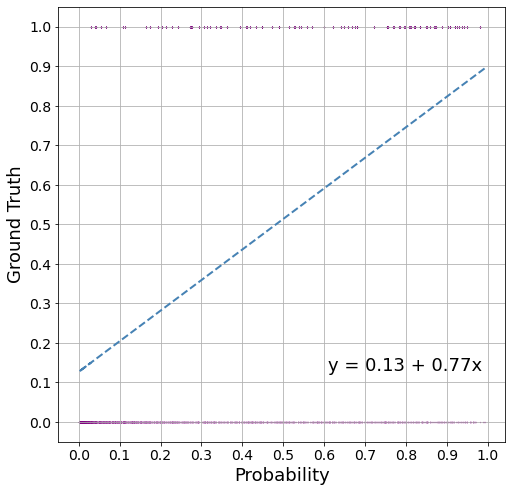

(0.1271048635517119, 0.7733149642209355)

In [25]:
plot_probability_curve(results_test)

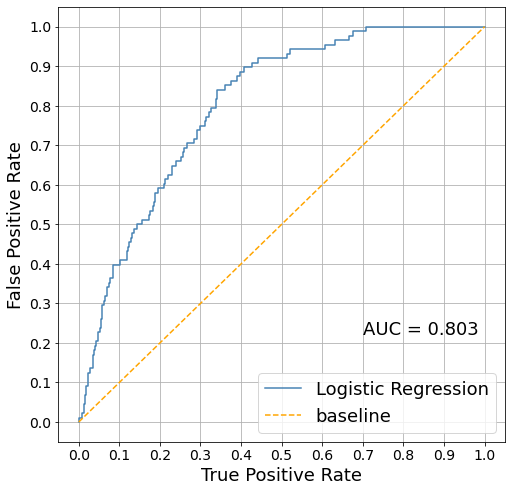

(0.3404, 0.8409, 0.2728, 0.7448)

In [26]:
plot_roc_curve(results_test)

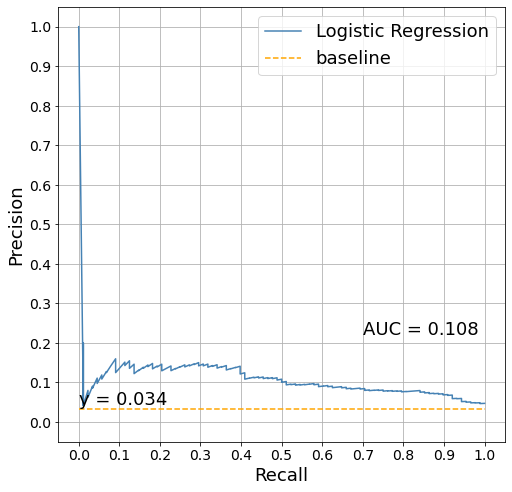

(0.4886, 0.11, 0.64, 0.2921)

In [39]:
plot_pr_curve(results_test, plot_fbeta = False)

In [28]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 58.28%
Weighted Average: 59.72%

Random Average: 22.45%
Random Weighted Average: 24.00%


In [29]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/07/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/07/2010,1,0,0.20,1,0.00 %,0.0000,20.00 %,0.2000
2,01/08/2010,1,0,0.19,1,0.00 %,0.0000,19.00 %,0.1900
3,16/08/2010,2,1,0.44,2,50.00 %,0.5000,22.00 %,0.2200
4,01/09/2010,2,1,0.35,2,50.00 %,0.5000,17.50 %,0.1750
...,...,...,...,...,...,...,...,...,...
99,16/08/2022,4,3,0.77,4,75.00 %,0.7500,19.25 %,0.1925
100,01/09/2022,2,2,0.38,2,100.00 %,1.0000,19.00 %,0.1900
101,16/09/2022,4,2,0.72,4,50.00 %,0.5000,18.00 %,0.1800
102,01/10/2022,3,2,0.65,3,66.67 %,0.6667,21.67 %,0.2167


In [30]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,6,2,1.18,6,33.33 %,0.3333,19.67 %,0.1967
1,2011,23,10,4.86,19,52.63 %,0.5263,25.58 %,0.2558
2,2012,0,0,0.00,0,nan %,NaN,nan %,NaN
3,2013,0,0,0.00,0,nan %,NaN,nan %,NaN
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,5,5,1.08,5,100.00 %,1.0000,21.60 %,0.2160
9,2019,30,15,5.97,22,68.18 %,0.6818,27.14 %,0.2714


In [31]:
report_train, report_test = classification_report_new(results_train, results_test, threshold = 0.2, beta = 4)

In [32]:
report_train

,Accuracy,Precision,Recall,F4 Score,Loss
0,0.7765,0.1926,0.9738,0.7863,0.3728


In [33]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.1600,0.7612,0.1250,0.6667,0.5312,0.1606
1,2011,23.0000,0.4000,0.7407,0.2375,0.8261,0.7210,0.3974
2,2012,0.0000,0.6800,0.3200,0.0000,0.0000,0.0000,1.0460
3,2013,0.0000,0.2950,0.7050,0.0000,0.0000,0.0000,0.2269
4,2014,0.0000,0.1750,0.8250,0.0000,0.0000,0.0000,0.1281
5,2015,0.0000,0.5050,0.4950,0.0000,0.0000,0.0000,0.5769
6,2016,0.0000,0.0700,0.9300,0.0000,0.0000,0.0000,0.0738
7,2017,0.0000,0.6600,0.3400,0.0000,0.0000,0.0000,0.6710
8,2018,5.0000,0.5700,0.6179,0.0351,0.8000,0.3505,0.5054
9,2019,30.0000,0.6650,0.6971,0.2256,1.0000,0.8320,0.5293


In [34]:
results_test

,lau1,day,month,year,case,score
0,λαρισαιων,16,7,2012,0,9.921256e-01
1,λαρισαιων,16,8,2012,0,9.897955e-01
2,λαρισαιων,1,8,2012,0,9.878288e-01
3,λαρισαιων,1,8,2015,0,9.805553e-01
4,λαρισαιων,1,8,2020,1,9.800152e-01
...,...,...,...,...,...,...
2595,σκοπελου,16,10,2015,0,3.791152e-06
2596,αλοννησου,16,10,2015,0,3.455928e-06
2597,αλοννησου,1,10,2015,0,3.090094e-06
2598,αλοννησου,16,10,2019,0,2.058087e-06


In [35]:
results_test[['lau1', 'day', 'month', 'year']].value_counts()

lau1          day  month  year
αγιας         1    7      2010    1
ρηγα φεραιου  16   9      2014    1
                   7      2022    1
                   8      2010    1
                          2011    1
                                 ..
καρδιτσας     1    9      2020    1
                          2021    1
                          2022    1
                   10     2010    1
φαρσαλων      16   10     2022    1
Length: 2600, dtype: int64

In [36]:
# results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [37]:
data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

object_cols = data_train.select_dtypes(include=['object']).columns.to_list()
removed_cols = features_to_remove

X_train = data_train.drop(columns = ['case'] + object_cols + removed_cols)
y_train = data_train['case']

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
           
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_value_counts = y_train.value_counts()
class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        
if (near_u != 0):
    if majority_class == 0:
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    elif majority_class == 1:
        nm = NearMiss(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 - near_u))}, version = 1, n_jobs = -1)

    X_train_resampled, y_train_resampled = nm.fit_resample(X_train_imputed, y_train)

    y_train_value_counts = y_train_resampled.value_counts()
    class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
    class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(class_0_counts * (1 + smote)), 1: class_1_counts}, n_jobs = -1, random_state = 0)

    if (near_u != 0):
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_resampled, y_train_resampled)
    else:
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

X_train_returned = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_returned = y_train if (near_u == 0 and smote == 0) else y_train_resampled

value_counts = y_train_returned.value_counts()
non_cases = value_counts.get(key = 0) if value_counts.get(key = 0) is not None else 0
cases = value_counts.get(key = 1) if value_counts.get(key = 1) is not None else 0
        
if non_cases >= cases:
    w0 = 1
    try:
        w1 = math.ceil(non_cases/cases)
    except ZeroDivisionError:
        w1 = 10
else:
    w1 = 1
    try:
        w0 = math.ceil(cases/non_cases)
    except ZeroDivisionError:
        w0 = 10
            
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

model.fit(X_train_returned, y_train_returned)

model

LogisticRegression(class_weight={0.0: 1, 1.0: 7}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [38]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model_new.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer_new.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler_new.pkl', 'wb'))